## Model Outputs

Suppose we provide an image as input to an Object Detection model.

The model must generate two different types of outputs:

```text
Input Image
      │
      ▼
 Feature Extraction
      │
 ┌────┴────┐
 ▼         ▼
Class   Bounding Box
```

Therefore:

* **Input:** Image
* **Output 1:** Object Class
* **Output 2:** Bounding Box Coordinates

The first output identifies **what the object is**, while the second output determines **where the object is located** within the image.

As a result, Object Detection can be viewed as a **multi-output learning problem**, where a single model simultaneously predicts both the object category and its spatial location.

```text
Prediction =
{
    Class,
    Bounding Box
}
```

This is one of the key differences between Image Classification and Object Detection. While a Classification model predicts only a class label, an Object Detection model must predict both the class and the object's location.


In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
IMAGE_DIR = 'dataset/images'
ANNOTATIONS_DIR = 'dataset/annotations'

class_names = [d for d in os.listdir(IMAGE_DIR) if os.path.isdir(os.path.join(IMAGE_DIR, d))]
csv_files = [f for f in os.listdir(ANNOTATIONS_DIR) if f.endswith('.csv')]

In [4]:
class_names

['airplane', 'face', 'motorcycle']

In [5]:
csv_files

['airplane.csv', 'face.csv', 'motorcycle.csv']

In [6]:
images = []
labels = []
annotations = []

for i in range(len(class_names)):
    class_name = class_names[i]
    class_dir = os.path.join(IMAGE_DIR, class_name)

    csv_file_name = csv_files[i]
    csv_path = os.path.join(ANNOTATIONS_DIR, csv_file_name)
    df = pd.read_csv(csv_path)
    
    for image_name in os.listdir(class_dir):
            image_path = os.path.join(class_dir, image_name)

            image = cv2.imread(image_path)
            h, w, _ = image.shape
            
            ann = df[df['image_name'] == image_name].iloc[0,1:].tolist()
            
            ann[0] = ann[0] / w
            ann[1] = ann[1] / h
            ann[2] = ann[2] / w
            ann[3] = ann[3] / h

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (224, 224))
        
            images.append(image)
            labels.append([class_names.index(class_name)])
            annotations.append([ann])

In [7]:
images = np.array(images)
labels = np.array(labels)
annotations = np.array(annotations)

In [8]:
images.dtype

dtype('uint8')

In [9]:
labels.dtype

dtype('int64')

In [10]:
annotations.dtype

dtype('float64')

In [11]:
images.shape

(2033, 224, 224, 3)

In [12]:
labels.shape

(2033, 1)

In [13]:
annotations.shape

(2033, 1, 4)

In [14]:
annotations.min()

0.0057306590257879654

In [15]:
annotations.max()

0.9941860465116279

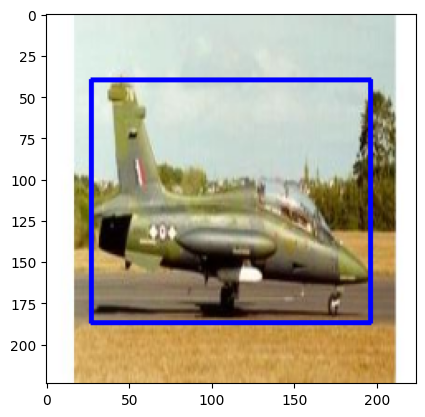

In [16]:
i = 0

img = images[i]
bbox = (annotations[i][0] * 224).astype(int)
img_ann = cv2.rectangle(img.copy(),bbox[:2],bbox[2:],color=(0,0,255),thickness=2)
plt.imshow(img_ann)

In [17]:
img.shape

(224, 224, 3)

In [19]:
import keras
import tensorflow as tf
from tensorflow.keras.layers import Flatten, Dropout, Dense, Input, MaxPool2D, Conv2D
from tensorflow.keras.models import Model

In [20]:
keras.__version__

'3.8.0'

# Why Functional API?

In a **Sequential** model, data flows through a single linear path from the input layer to the output layer.

```text
Input
  ↓
Layer 1
  ↓
Layer 2
  ↓
Output
```

This architecture works well for tasks that require only one output.

However, in our Object Detection problem:

* We have **one input image**.
* We need **two different outputs**.

  * Object Class
  * Bounding Box Coordinates

Conceptually:

```text
Input Image
      │
      ▼
 Feature Extraction
      │
 ┌────┴────┐
 ▼         ▼
Class   Bounding Box
```

Because the network branches into multiple outputs, a simple Sequential architecture is no longer sufficient.

The **Functional API** provides the flexibility needed to create models with multiple outputs, multiple inputs, shared layers, and more complex architectures.

Therefore, for an Object Detection model that predicts both the object class and its bounding box, the **Functional API** is a more appropriate choice than the Sequential API.


In [22]:
# input
input_model = Input(shape=(224, 224, 3), name='input_layer')

# Conv
conv = Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu')(input_model)
conv = MaxPool2D()(conv)
conv = Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu')(conv)
conv = MaxPool2D()(conv)
conv = Conv2D(filters=128, kernel_size=(3,3), strides=1, padding='same', activation='relu')(conv)
conv = MaxPool2D()(conv)
conv = Conv2D(filters=256, kernel_size=(3,3), strides=1, padding='same', activation='relu')(conv)
conv = MaxPool2D()(conv)
conv = Conv2D(filters=512, kernel_size=(3,3), strides=1, padding='same', activation='relu')(conv)
conv = MaxPool2D()(conv)

# flatten
flatten = Flatten()(conv)

# class label
clf = Dense(128, activation="relu")(flatten)
clf = Dropout(0.5)(clf)
clf = Dense(3, activation="softmax", name="class")(clf)

# bounding box
bbox = Dense(128, activation="relu")(flatten)
bbox = Dropout(0.5)(bbox)
bbox = Dense(4, activation="sigmoid", name="bbox")(bbox)

# make model
model = Model(inputs=input_model, outputs=(clf, bbox))

In [23]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 112, 112,  │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 56, 56,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_6[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 28, 28,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 28, 28,    │    295,168 │ max_pooling2d_7[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 14, 14,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │  1,180,160 │ max_pooling2d_8[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 7, 7, 512) │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 25088)     │          0 │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │  3,211,392 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │  3,211,392 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class (Dense)       │ (None, 3)         │        387 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox (Dense)        │ (None, 4)         │        516 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,992,263 (30.49 MB)

 Trainable params: 7,992,263 (30.49 MB)

 Non-trainable params: 0 (0.00 B)

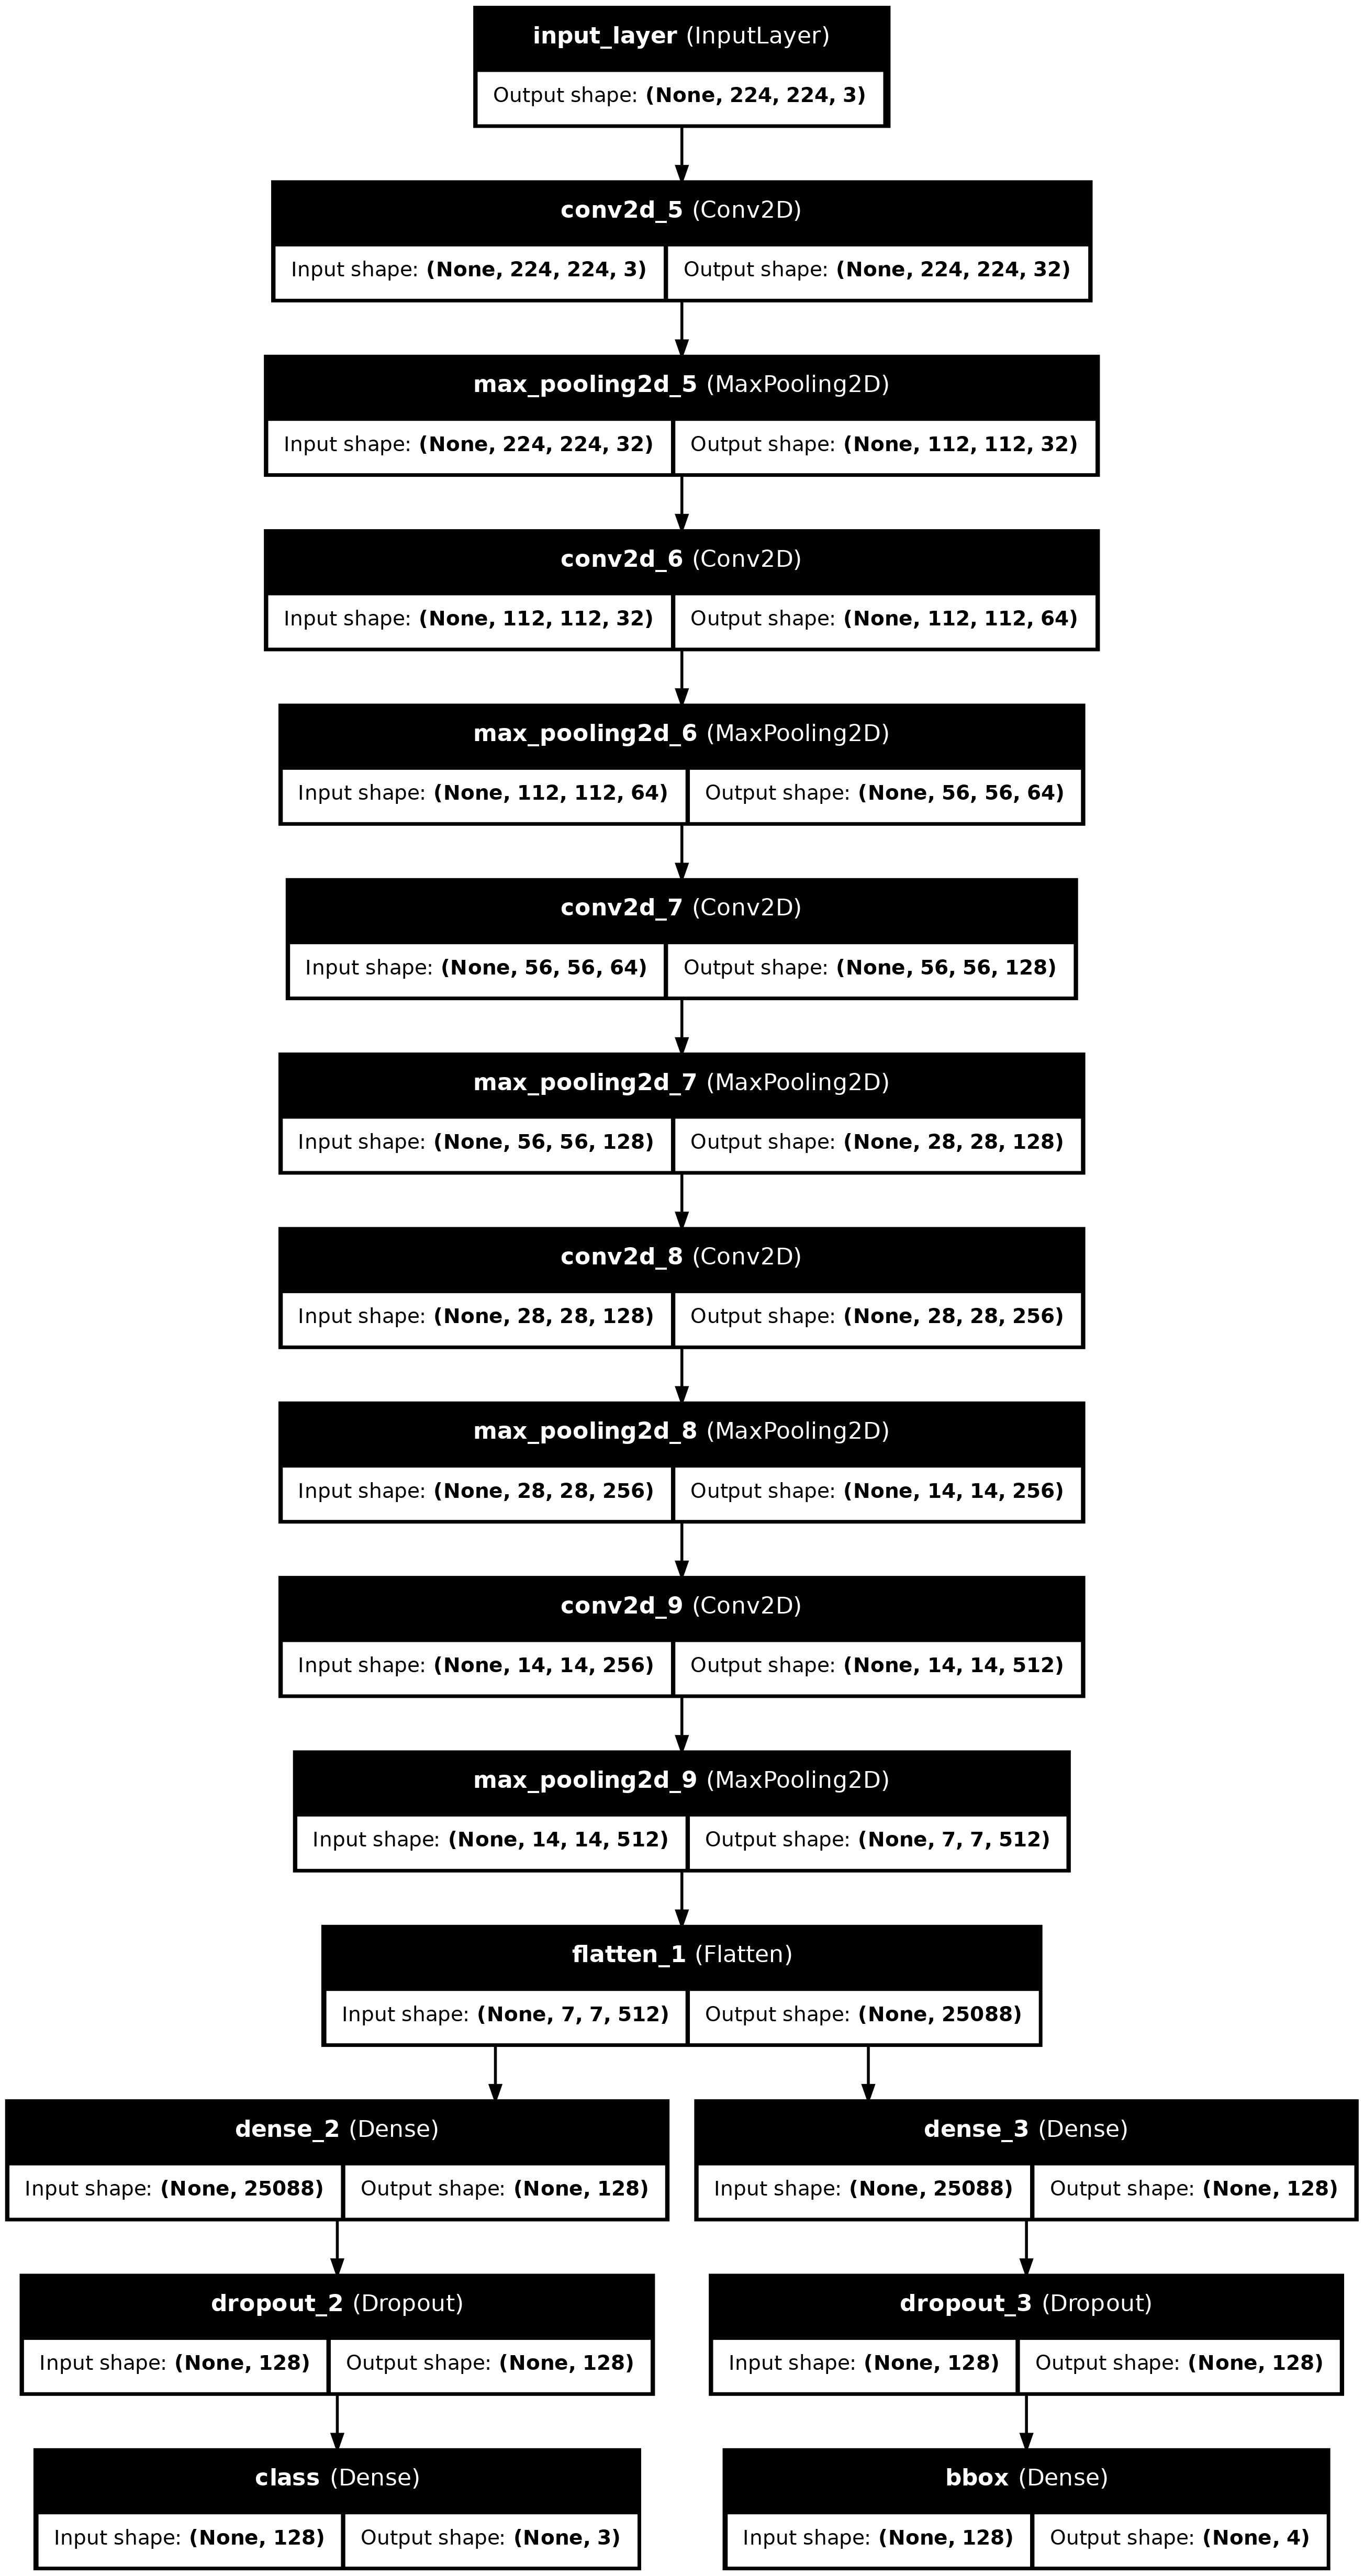

In [24]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='model.png',
    show_shapes=True,
    show_layer_names=True,
)

# Choosing the Loss Functions

Since the model has two different outputs, a separate loss function must be defined for each output.

### Classification Loss

For class prediction, we use:

```

SparseCategoricalCrossentropy

```


### Bounding Box Loss

For bounding box coordinate regression, we use:

```

MeanSquaredError

```
```


## How is the Final Loss Computed?

The model computes two independent loss functions:

- L_class
- L_bbox

The final loss is then calculated as:

Total Loss =
w1 × L_class +
w2 × L_bbox

In this project:

w1 = 1
w2 = 1

Therefore, both components are given equal importance.

In [25]:
opt = tf.optimizers.Adam(learning_rate=0.001)

loss = {
    'class':tf.losses.SparseCategoricalCrossentropy(),
    'bbox': tf.losses.MeanSquaredError()}

loss_weights = {
    'class': 1.0,
    'bbox': 1.0
}

metrics = {
    'class': tf.metrics.SparseCategoricalAccuracy(),
    'bbox': tf.metrics.MeanSquaredError()
}

model.compile(optimizer=opt,loss=loss,metrics=metrics,loss_weights=loss_weights)

## Reduce Learning Rate

If the model does not show any improvement for several epochs:

```python
ReduceLROnPlateau(...)
```

the learning rate is reduced.

This helps the model converge more effectively.


In [26]:
callbacks = [keras.callbacks.ModelCheckpoint(filepath='best_model.keras',monitor='val_loss'),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss" ,factor=0.1,patience=12)]

In [27]:
images.max()

255

In [28]:
X_train = images / 255

In [29]:
y_train = [labels,annotations]

In [30]:
history = model.fit(X_train, y_train,batch_size=32,epochs=100,validation_split=0.15,verbose=1,callbacks=callbacks)

Epoch 1/100


I0000 00:00:1746368146.303023    1047 service.cc:148] XLA service 0x7f1da4113c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746368146.303446    1047 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6
2025-05-04 17:45:46.343019: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746368146.531600    1047 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-05-04 17:45:47.232678: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 28 bytes spill stores, 28 bytes spill loads



 3/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - bbox_loss: 0.0841 - bbox_mean_squared_error: 0.0841 - class_loss: 1.2324 - class_sparse_categorical_accuracy: 0.4167 - loss: 1.3166

I0000 00:00:1746368153.431907    1047 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - bbox_loss: 0.0370 - bbox_mean_squared_error: 0.0370 - class_loss: 0.9324 - class_sparse_categorical_accuracy: 0.5475 - loss: 0.9694 - val_bbox_loss: 0.0126 - val_bbox_mean_squared_error: 0.0125 - val_class_loss: 0.2350 - val_class_sparse_categorical_accuracy: 0.9607 - val_loss: 0.2437 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - bbox_loss: 0.0158 - bbox_mean_squared_error: 0.0158 - class_loss: 0.2202 - class_sparse_categorical_accuracy: 0.9281 - loss: 0.2361 - val_bbox_loss: 0.0076 - val_bbox_mean_squared_error: 0.0077 - val_class_loss: 0.0187 - val_class_sparse_categorical_accuracy: 1.0000 - val_loss: 0.0266 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - bbox_loss: 0.0133 - bbox_mean_squared_error: 0.0133 - class_loss: 0.1034 - class_sparse_categorical_accuracy: 0.9679 - loss: 0.1167 - val_bbox_loss: 0.0061 - val_bbox_mean_squared_error: 0.0061 - val_class_loss: 0.0038 - val_cla

In [31]:
history.history

{'bbox_loss': [0.02416546642780304,
  0.015870235860347748,
  0.01337810792028904,
  0.012364274822175503,
  0.011802132241427898,
  0.0112131517380476,
  0.01047053374350071,
  0.010246449150145054,
  0.010154222138226032,
  0.011020146310329437,
  0.009766919538378716,
  0.010803017765283585,
  0.009973127394914627,
  0.00928885955363512,
  0.009349937550723553,
  0.008827566169202328,
  0.008721661753952503,
  0.008412481285631657,
  0.008413778617978096,
  0.008280404843389988,
  0.008363323286175728,
  0.007960601709783077,
  0.007999471388757229,
  0.007982083596289158,
  0.0075772306881845,
  0.007868766784667969,
  0.007470369338989258,
  0.007534304168075323,
  0.007509633898735046,
  0.007465475704520941,
  0.007622327655553818,
  0.007433048915117979,
  0.007459393236786127,
  0.007483372930437326,
  0.007554506883025169,
  0.007462486624717712,
  0.0074231973849236965,
  0.007471017073839903,
  0.007483873516321182,
  0.0074426839128136635,
  0.007441897410899401,
  0.00736

In [32]:
history.history.keys()

dict_keys(['bbox_loss', 'bbox_mean_squared_error', 'class_loss', 'class_sparse_categorical_accuracy', 'loss', 'val_bbox_loss', 'val_bbox_mean_squared_error', 'val_class_loss', 'val_class_sparse_categorical_accuracy', 'val_loss', 'learning_rate'])

In [33]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
class_loss = history.history['class_loss']
val_class_loss = history.history['val_class_loss']
bbox_loss = history.history['bbox_loss']
val_bbox_loss = history.history['val_bbox_loss']

train_class_accuracy = history.history['class_sparse_categorical_accuracy']
val_class_accuracy = history.history['val_class_sparse_categorical_accuracy']

epochs = len(train_loss)

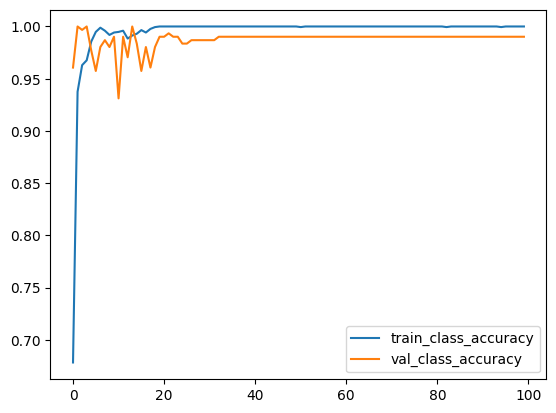

In [34]:
plt.plot(train_class_accuracy,label='train_class_accuracy')
plt.plot(val_class_accuracy,label='val_class_accuracy')
plt.legend()
plt.show()

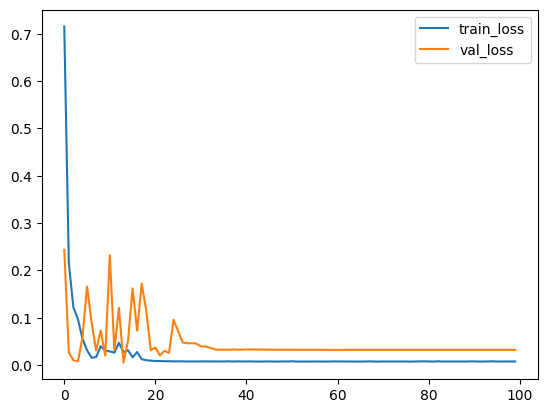

In [35]:
plt.plot(train_loss,label='train_loss')
plt.plot(val_loss,label='val_loss')
plt.legend()
plt.show()

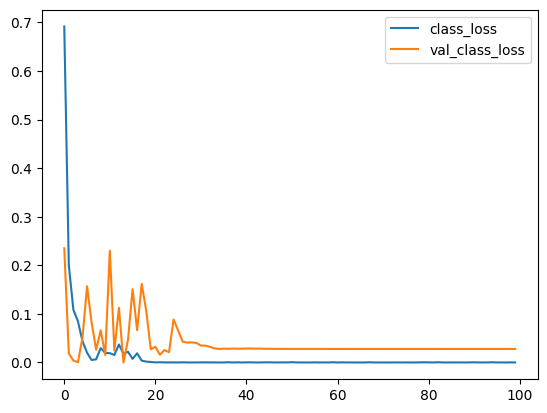

In [36]:
plt.plot(class_loss,label='class_loss')
plt.plot(val_class_loss,label='val_class_loss')
plt.legend()
plt.show()

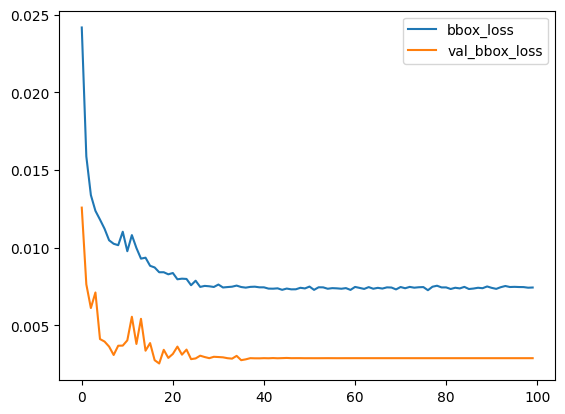

In [37]:
plt.plot(bbox_loss,label='bbox_loss')
plt.plot(val_bbox_loss,label='val_bbox_loss')
plt.legend()
plt.show()

# Summary

* We prepared the dataset.
* We loaded the images, labels, and bounding boxes.
* We normalized the bounding box coordinates.
* We designed a Multi-Output model.
* We used the Functional API.
* We created two independent outputs for Classification and Localization.
* We defined separate loss functions.
* We trained the model.
* We evaluated the results.
* We tested the model on new images.

Although the bounding box prediction is not yet ideal, the main goal was to understand the structure of a simple Object Detection model and learn how to implement Classification and Localization simultaneously.


In [38]:
### predict

In [8]:
import tensorflow as tf
import keras
import cv2
import matplotlib.pyplot as plt

In [9]:
model = keras.saving.load_model('best_model.keras')

In [26]:
image_path = 'test/images.jpg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))

X = tf.expand_dims(image, axis=0) / 255

In [27]:
X.shape

TensorShape([1, 224, 224, 3])

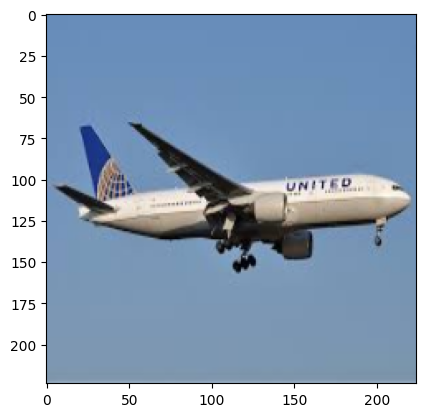

In [28]:
plt.imshow(image)
plt.show()

In [29]:
model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


[array([[1.0000000e+00, 1.1211223e-15, 4.7515926e-14]], dtype=float32),
 array([[0.19901511, 0.16981804, 0.8094228 , 0.81679237]], dtype=float32)]

In [30]:
class_perd, bbox_pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [31]:
class_names = ['airplane', 'face', 'motorcycle']

In [32]:
class_pred_label = class_names[class_perd.argmax()]

In [33]:
class_pred_label

'airplane'

In [34]:
bbox_pred = (bbox_pred * 224).astype('int')

In [35]:
bbox_pred

array([[ 44,  38, 181, 182]])

In [36]:
cord1 = bbox_pred[0][:2]
cord2 = bbox_pred[0][2:]

In [37]:
img_test_bbox = cv2.rectangle(image,cord1,cord2,color=(0,0,255),thickness=2)
img_test_bbox = cv2.putText(img_test_bbox,class_pred_label,cord1,cv2.FONT_HERSHEY_COMPLEX,0.6,color=(0,0,255))

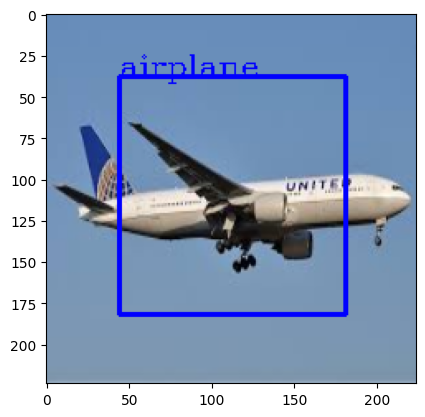

In [38]:
plt.imshow(img_test_bbox)